In [75]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import eigh
from scipy.special import gamma
from opt_einsum import contract
#!pip install git+https://github.com/HyQD/grid-lib
from grid_lib.spherical_coordinates.analytical_radial_functions import Rnl_HO, Rn_STO, Rnl_LF
from grid_lib.pseudospectral_grids.gauss_legendre_lobatto import (
    GaussLegendreLobatto,
    Linear_map,
)
from grid_lib.pseudospectral_grids.femdvr import FEMDVR
from grid_lib.spherical_coordinates.angular_momentum import (
    LM_to_I,
    number_of_lm_states,
)
from grid_lib.spherical_coordinates.angular_matrix_elements import (
    AngularMatrixElements,
)

In [76]:
#Compute overlap, kinetic, and potential matrices

def compute_matrices(basis, Z=1.0, r_max=75.0, element_size=2.0, n_points_pr_element=11, l_max=0, m_max=0, z_omega=None): 


    # Define the radial grid and the number of points per element
    r_start = 0.0
    nodes = np.arange(r_start, r_max + element_size, element_size)
    n_points = (
        np.ones((len(nodes) - 1,), dtype=int) * n_points_pr_element
    )  # Example number of points per element

    GLL = FEMDVR(nodes, n_points, Linear_map, GaussLegendreLobatto)
    r = GLL.r[1:-1]  # Exclude the endpoints
    weights = GLL.weights[1:-1]  # Exclude the endpoints
    D2 = GLL.D2[1:-1, 1:-1]  # Exclude the endpoints

    get_nabla_sq = lambda l: D2 - np.diag(l * (l + 1) / r**2)
    
    # Initialize matrices
    n_bf = len(basis)
    Spq = np.zeros((n_bf, n_bf))
    Tpq = np.zeros((n_bf, n_bf))
    Vpq = np.zeros((n_bf, n_bf))

    if z_omega is not None:
        z_pq = np.zeros((n_bf, n_bf))

    # Compute matrix elements
    for p in range(n_bf):
        lp, mp, phi_p0 = basis[p]
        phi_p = phi_p0(r)
        nabla_sq = get_nabla_sq(lp)
        for q in range(n_bf):
            lq, mq, phi_q0 = basis[q]
            phi_q = phi_q0(r)
            
            if lp == lq and mp == mq:
                Spq[p, q] = contract("i,i->", weights, phi_p * phi_q)
                Tpq[p, q] = -0.5*contract("i, i, i ->", phi_p, nabla_sq @ phi_q, weights)
                Vpq[p, q] = -Z*contract("i,i->", weights, phi_p * phi_q / r)
            
            if z_omega is not None:
                z_pq[p,q] = z_omega[LM_to_I(lp, mp, l_max, m_max), LM_to_I(lq, mq, l_max, m_max)] * contract("i,i->", weights, r*phi_p * phi_q)

    # Form Hcore (Hpq)
    Hpq = Tpq + Vpq
    # Check that Hpq is symmetric
    assert np.allclose(Hpq, Hpq.T), "Hamiltonian matrix is not symmetric"
    
    if z_omega is not None:
        return Spq, Tpq, Vpq, Hpq, z_pq, r
    else:
        return Spq, Tpq, Vpq, Hpq, r

def compute_basis_overlap(basis, basis2, r_max=75.0, element_size=2.0, n_points_pr_element=11):
    # Define the radial grid and the number of points per element
    r_start = 0.0
    nodes = np.arange(r_start, r_max + element_size, element_size)
    n_points = (
        np.ones((len(nodes) - 1,), dtype=int) * n_points_pr_element
    )  # Example number of points per element

    GLL = FEMDVR(nodes, n_points, Linear_map, GaussLegendreLobatto)
    r = GLL.r[1:-1]  # Exclude the endpoints
    weights = GLL.weights[1:-1]  # Exclude the endpoints

    n_bf1 = len(basis)
    n_bf2 = len(basis2)
    S12 = np.zeros((n_bf1, n_bf2))

    for p in range(n_bf1):
        lp, mp, phi_p0 = basis[p]
        phi_p = phi_p0(r)
        for q in range(n_bf2):
            lq, mq, phi_q0 = basis2[q]
            phi_q = phi_q0(r)
            
            if lp == lq and mp == mq:
                S12[p, q] = contract("i,i->", weights, phi_p * phi_q)

    return S12


In [77]:
# kaufmann coefficients
def kaufmann_gto(r, n, l, zeta):
    a = np.array([0.584342, 0.452615, 0.382362, 0.337027, 0.304679])
    b = np.array([0.424483, 0.309805, 0.251333, 0.215013, 0.189944])
    alpha = (zeta/(2*a[l]*n + 2*b[l]))**2
    N = np.sqrt((2 * (2*alpha)**(l + 1.5) / (gamma(l + 1.5))))
    
    return N * r**l * np.exp(-alpha * r**2)


In [78]:
# Define the radial grid and the number of points per element
r_start = 0.0
r_max = 120.0
element_size = 1.0
n_points_pr_element = 11


zeta_sto = 1.0  # Exponent for STO functions
l_max = 4
n_l = l_max + 1
m_max = 0
n_lm = number_of_lm_states(l_max, m_max)
n_max = 10

In [79]:
ame = AngularMatrixElements(l_max=l_max, N=101)
z_omega = np.zeros((n_lm, n_lm)) # <l1,m1|cos(theta)|l2,m2>

for m1 in range(-m_max, m_max + 1):
    for l1 in range(abs(m1), n_l):
        I_l1m1 = LM_to_I(l1, m1, l_max, m_max)
        for m2 in range(-m_max, m_max + 1):
            for l2 in range(abs(m2), n_l):
                I_l2m2 = LM_to_I(l2, m2, l_max, m_max)
                z_omega[I_l1m1, I_l2m2] = ame.l1m1_costh_l2m2(l1, m1, l2, m2)

In [80]:
#Setup the basis functions

basis = []
basis2 = []

for l in range(0, n_l):
     for m in range(-m_max,m_max+1):
        for n in range(1, n_max + 1):
            phi = lambda r, n=n: r * Rn_STO(r, n, zeta=zeta_sto)
            basis.append((l,m,phi))
            
            phi2 = lambda r, n=n: r * kaufmann_gto(r, n, l, zeta_sto)
            basis2.append((l,m,phi2))
    
n_bf = len(basis)
print(f"Number of basis functions: {n_bf}")

S, T, V, H, Z, r = compute_matrices(basis, r_max=r_max, element_size=element_size, n_points_pr_element=n_points_pr_element, l_max=l_max, m_max=m_max, z_omega=z_omega)
S2, T2, V2, H2, Z2, r = compute_matrices(basis2, r_max=r_max, element_size=element_size, n_points_pr_element=n_points_pr_element, l_max=l_max, m_max=m_max, z_omega=z_omega)



Number of basis functions: 50


/tmp/ipykernel_24626/2012808932.py:9: RuntimeWarning: invalid value encountered in arccos
  theta = np.arccos(sigma)


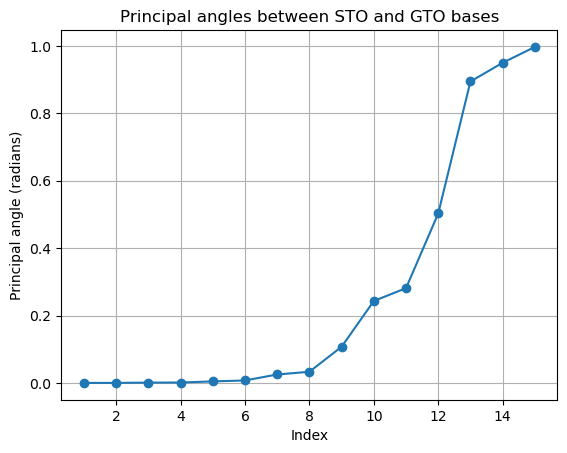

In [81]:

def get_angles(basis, basis2, block_size=10):
    S = compute_basis_overlap(basis, basis, r_max=r_max, element_size=element_size, n_points_pr_element=n_points_pr_element)
    S2 = compute_basis_overlap(basis2, basis2, r_max=r_max, element_size=element_size, n_points_pr_element=n_points_pr_element)
    S12 = compute_basis_overlap(basis, basis2, r_max=r_max, element_size=element_size, n_points_pr_element=n_points_pr_element)
    omega, X = np.linalg.eigh(S[:block_size, :block_size])
    omega2, X2 = np.linalg.eigh(S2[:block_size, :block_size])
    Q = X @ np.diag(omega**-.5) @ X.T @ S12[:block_size, :block_size] @ X2 @ np.diag(omega2**-0.5) @ X2.T
    A, sigma, B = np.linalg.svd(Q)
    theta = np.arccos(sigma)
    plt.figure()
    plt.plot(2*theta/np.pi, marker='o')
    plt.xlabel('Index')
    plt.ylabel('Principal angle (radians)')
    plt.title('Principal angles between STO and GTO bases')
    plt.grid()
    plt.show()
    
get_angles(basis, basis2, block_size=16)


/tmp/ipykernel_24626/2382826815.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


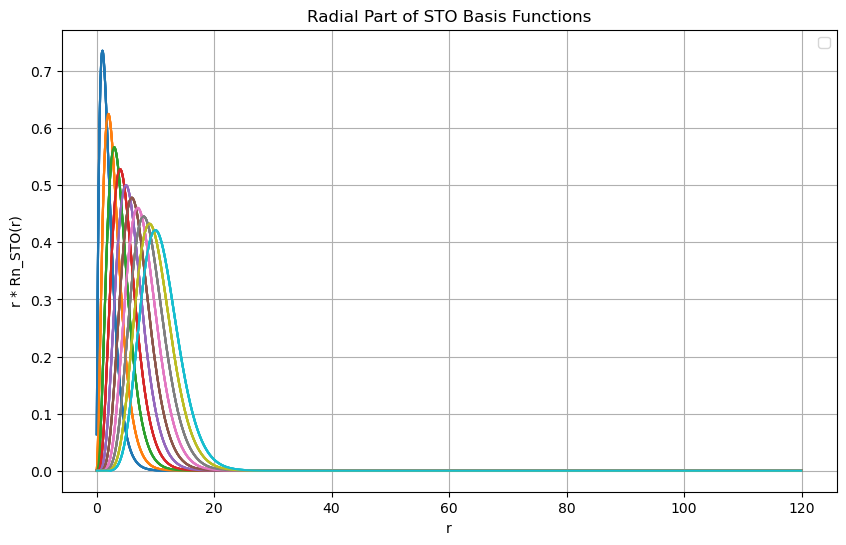

/tmp/ipykernel_24626/2382826815.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


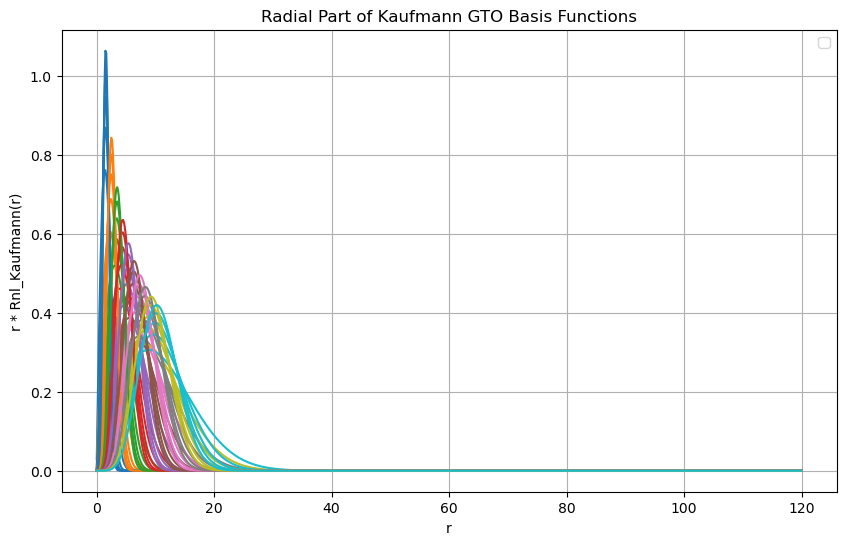

In [82]:


plt.figure(figsize=(10, 6))
for l, m, phi in basis:
    plt.plot(r, phi(r)) #, label=f"n={basis.index((l,m,phi))+1}, l={l}, m={m}")
    

plt.title("Radial Part of STO Basis Functions")
plt.xlabel("r")
plt.ylabel("r * Rn_STO(r)")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
for l, m, phi in basis2:
    plt.plot(r, phi(r)) #, label=f"n={basis2.index((l,m,phi))+1}, l={l}, m={m}")
    

plt.title("Radial Part of Kaufmann GTO Basis Functions")
plt.xlabel("r")
plt.ylabel("r * Rnl_Kaufmann(r)")
plt.legend()
plt.grid()
plt.show()

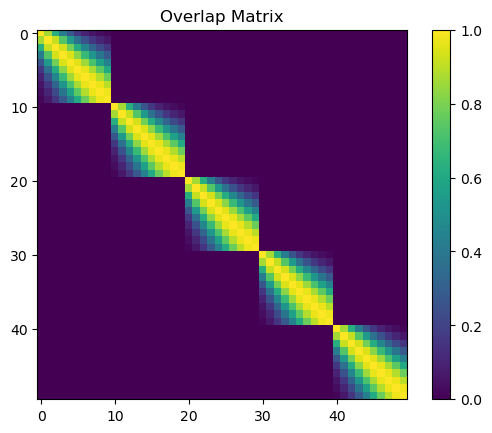

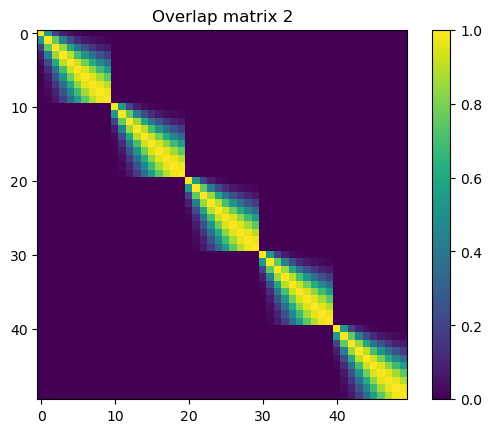

In [83]:
plt.figure()
plt.title("Overlap Matrix")
plt.imshow(S)
plt.colorbar()

plt.figure()
plt.title("Overlap matrix 2")
plt.imshow(S2)
plt.colorbar()

plt.show()

In [84]:
np.diag(S2 - np.ones_like(S2))

array([-5.85753668e-13,  0.00000000e+00, -2.22044605e-16, -2.22044605e-16,
       -2.22044605e-16, -2.22044605e-16, -1.11022302e-16,  0.00000000e+00,
       -2.22044605e-16, -3.33066907e-16, -5.85753668e-13,  0.00000000e+00,
       -2.22044605e-16, -2.22044605e-16, -2.22044605e-16, -2.22044605e-16,
       -1.11022302e-16,  0.00000000e+00, -2.22044605e-16, -3.33066907e-16,
       -5.85753668e-13,  0.00000000e+00, -2.22044605e-16, -2.22044605e-16,
       -2.22044605e-16, -2.22044605e-16, -1.11022302e-16,  0.00000000e+00,
       -2.22044605e-16, -3.33066907e-16, -5.85753668e-13,  0.00000000e+00,
       -2.22044605e-16, -2.22044605e-16, -2.22044605e-16, -2.22044605e-16,
       -1.11022302e-16,  0.00000000e+00, -2.22044605e-16, -3.33066907e-16,
       -5.85753668e-13,  0.00000000e+00, -2.22044605e-16, -2.22044605e-16,
       -2.22044605e-16, -2.22044605e-16, -1.11022302e-16,  0.00000000e+00,
       -2.22044605e-16, -3.33066907e-16])

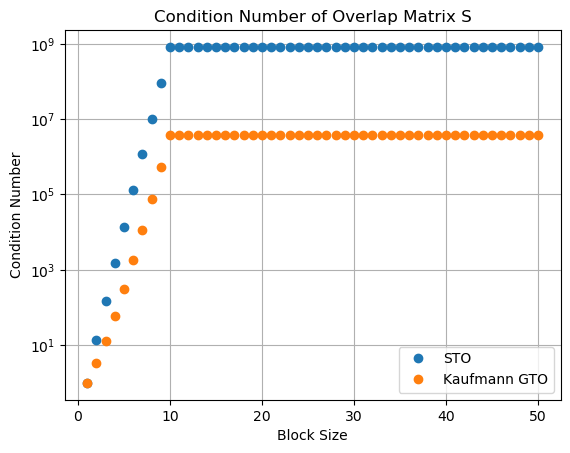

In [85]:
# plot condition number of S for increasing blocks
plt.figure()
plt.title("Condition Number of Overlap Matrix S")
kappa = []
kappa2 = []
for block_size in range(1, n_bf + 1):
    kappa.append(np.linalg.cond(S[:block_size, :block_size]))
    kappa2.append(np.linalg.cond(S2[:block_size, :block_size]))
plt.plot(range(1, n_bf + 1), kappa, 'o', label="STO")
plt.plot(range(1, n_bf + 1), kappa2, 'o', label="Kaufmann GTO")
plt.xlabel("Block Size")
plt.ylabel("Condition Number")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

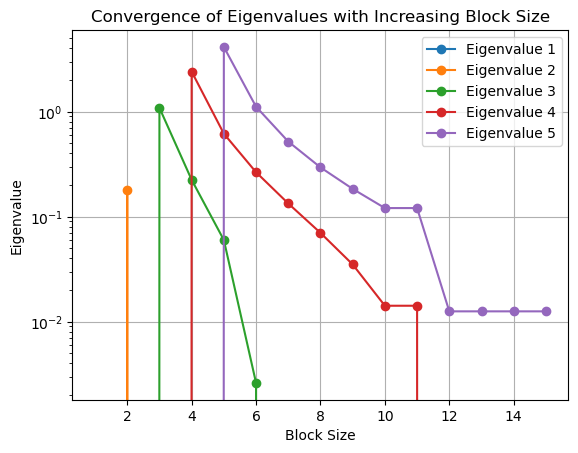

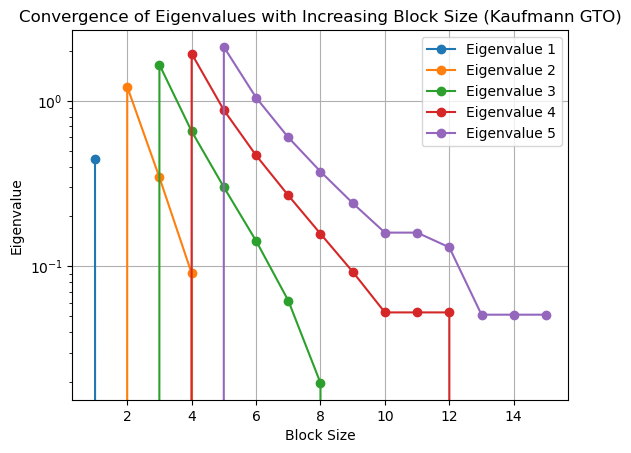

In [86]:
# plot convergence of eigenvalues with increasing blocks

max_block_size = 15
nev = 5
E_exact = -0.5 / ((np.abs(l)+np.arange(1, nev + 1))**2)  # Exact eigenvalues for hydrogenic atom
E_error = np.zeros((max_block_size,nev))
E_error2 = np.zeros((max_block_size,nev))
for block_size in range(1, max_block_size + 1):
    H_block = H[:block_size, :block_size]
    S_block = S[:block_size, :block_size]
    E_block, U_block = eigh(H_block, S_block)

    H_block2 = H2[:block_size, :block_size]
    S_block2 = S2[:block_size, :block_size]
    E_block2, U_block2 = eigh(H_block2, S_block2)

    #print(E_block.shape, U_block.shape)
    #print(E_block.shape, E_exact.shape)
    if nev <= len(E_block):
        E_error[block_size-1, :nev] = E_block[:nev] - E_exact  # Store the error for each eigenvalue
        E_error2[block_size-1, :nev] = E_block2[:nev] - E_exact  # Store the error for each eigenvalue
    else:
        E_error[block_size-1, :len(E_block)] = E_block - E_exact[:len(E_block)]  # Store the error for available eigenvalues
        E_error2[block_size-1, :len(E_block2)] = E_block2 - E_exact[:len(E_block2)]  # Store the error for available eigenvalues

plt.figure()
plt.title("Convergence of Eigenvalues with Increasing Block Size")

for k in range(nev):
    plt.plot(range(1, max_block_size + 1), E_error[:, k], 'o-', label=f"Eigenvalue {k+1}")
    
plt.xlabel("Block Size")
plt.ylabel("Eigenvalue")
plt.yscale("log")
plt.grid()
plt.legend()

plt.figure()
plt.title("Convergence of Eigenvalues with Increasing Block Size (Kaufmann GTO)")
for k in range(nev):
    plt.plot(range(1, max_block_size + 1), E_error2[:, k], 'o-', label=f"Eigenvalue {k+1}")
plt.xlabel("Block Size")
plt.ylabel("Eigenvalue")
plt.yscale("log")
plt.grid()
plt.legend()

plt.show()


In [87]:
E, U = eigh(H, S)
E2, U2 = eigh(H2, S2)

/tmp/ipykernel_24626/3691522199.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(U)))
/tmp/ipykernel_24626/3691522199.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(U2)))


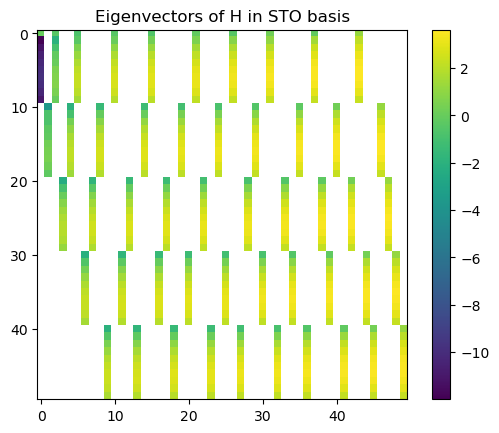

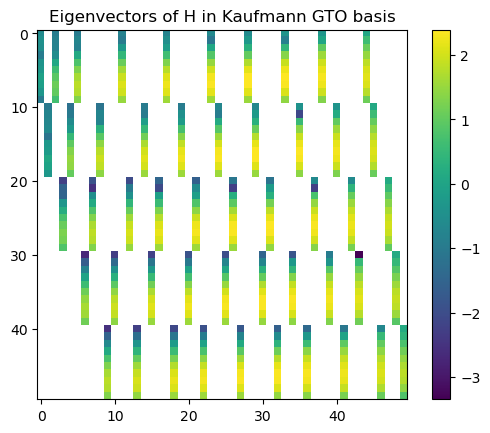

In [88]:
plt.figure()
plt.imshow(np.log10(np.abs(U)))
plt.colorbar()
plt.title("Eigenvectors of H in STO basis")
plt.figure()
plt.imshow(np.log10(np.abs(U2)))
plt.colorbar()
plt.title("Eigenvectors of H in Kaufmann GTO basis")
plt.show()  

In [89]:
E

array([-5.00000000e-01, -1.24999642e-01, -1.24999121e-01, -5.48399695e-02,
       -5.36760652e-02, -5.28243551e-02, -2.34860332e-02, -1.22468978e-02,
       -9.46785524e-04,  2.97340561e-03,  6.35217447e-03,  3.04145045e-02,
        6.15011589e-02,  7.53387914e-02,  9.25693865e-02,  1.14495237e-01,
        1.28711809e-01,  1.90789841e-01,  2.02409536e-01,  2.57554244e-01,
        2.99671886e-01,  3.11635042e-01,  4.19657844e-01,  4.24049765e-01,
        5.60749454e-01,  6.08813570e-01,  6.94473146e-01,  8.34695913e-01,
        8.56557656e-01,  1.18293464e+00,  1.22529010e+00,  1.55545654e+00,
        1.68766136e+00,  1.81933641e+00,  2.68180553e+00,  2.74762851e+00,
        3.81695907e+00,  4.12121901e+00,  4.56380892e+00,  7.28193238e+00,
        8.65660829e+00,  1.09324029e+01,  1.77377456e+01,  1.88741922e+01,
        3.15275509e+01,  4.99730402e+01,  8.36815776e+01,  2.15417688e+02,
        4.13239293e+02,  6.77050464e+02])

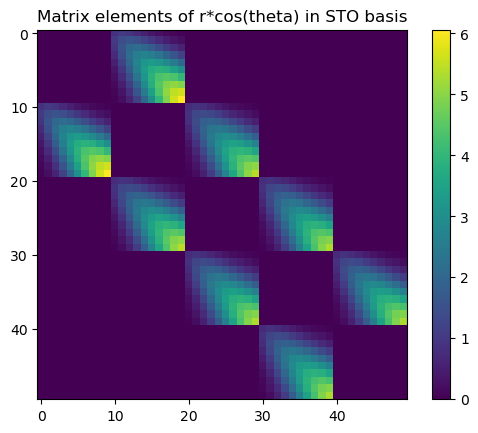

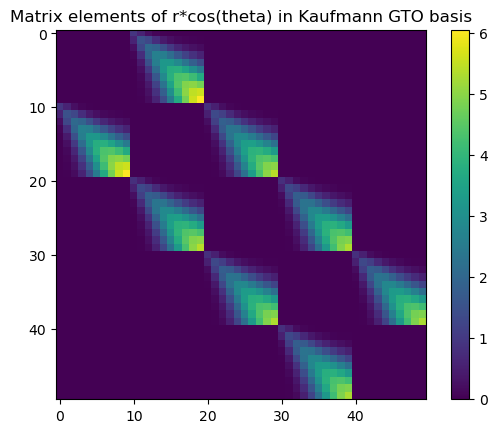

In [90]:
plt.figure()
plt.imshow(Z)
plt.colorbar()
plt.title("Matrix elements of r*cos(theta) in STO basis")
plt.figure()
plt.imshow(Z2)
plt.colorbar()
plt.title("Matrix elements of r*cos(theta) in Kaufmann GTO basis")
plt.show()

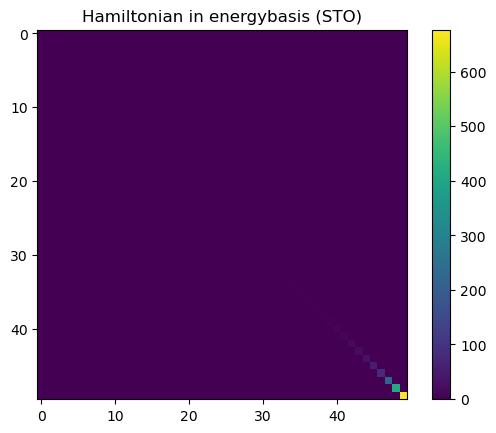

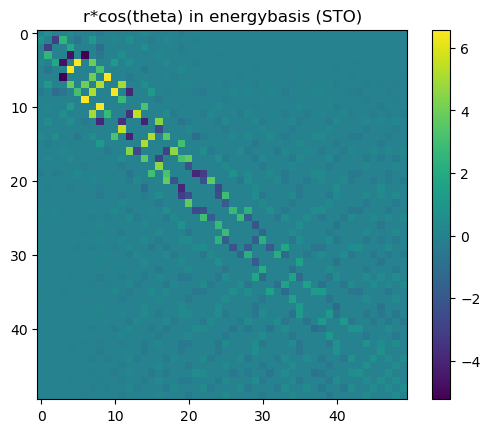

In [102]:
H_eb = contract("ap, bq, ab->pq", U.conj(), U, H)
Z_eb = contract("ap, bq, ab->pq", U.conj(), U, Z)

plt.figure()
plt.imshow(H_eb)
plt.colorbar()
plt.title("Hamiltonian in energybasis (STO)")
plt.figure()
plt.imshow(Z_eb)
plt.colorbar()
plt.title("r*cos(theta) in energybasis (STO)")
plt.show()